In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from bjontegaard import bd_rate, bd_psnr

Load Quantized Dataframe

In [62]:

# rótulos, na ordem informada
COLS_QUANTIZED = ['a', 'w', 'calib_res', 'calib_seq', 'frames',
           'dataset', 'quality', 'seq', 'bpp', 'psnr']


RESULTS_QUANTIZED_PATH = "ZRESULTS.txt"

df = pd.read_csv(
    RESULTS_QUANTIZED_PATH,
    header=None,
    names=COLS_QUANTIZED,
    sep=",",
    skipinitialspace=True,   # ignora espaços após vírgulas
    engine="python"          # robusto a pequenas variações
)

    # conversão de tipos (opcional, mas útil)
for c in ['a', 'w', 'calib_res', 'calib_seq', 'frames', 'quality']:
    df[c] = pd.to_numeric(df[c], errors='coerce', downcast='integer')
for c in ['bpp', 'psnr']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df_quant_allq = df
df_quant = df[df['quality'] % 2 != 0]

Load Anchor Dataframe

In [63]:
COLS_ANCHOR = ['frames', 'dataset', 'quality', 'seq', 'bpp', 'psnr']

RESULTS_ANCHOR_PATH = "ZRESULTS_ANCHOR.txt"

df = pd.read_csv(
    RESULTS_ANCHOR_PATH,
    header=None,
    names=COLS_ANCHOR,
    sep=",",
    skipinitialspace=True,   # ignora espaços após vírgulas
    engine="python"          # robusto a pequenas variações
)

    # conversão de tipos (opcional, mas útil)
for c in ['frames', 'quality']:
    df[c] = pd.to_numeric(df[c], errors='coerce', downcast='integer')
for c in ['bpp', 'psnr']:
    df[c] = pd.to_numeric(df[c], errors='coerce')


df_anchor_allq = df
df_anchor = df[df['quality'] % 2 != 0]

In [64]:
print("QUANTIZED:\n",df_quant.head())

print("\n\nANCHOR:\n",df_anchor.head())

QUANTIZED:
    a  w  calib_res  calib_seq  frames dataset  quality            seq  \
0  4  4        256       1000      32     UVG        1         Beauty   
1  4  4        256       1000      32     UVG        1      Bosphorus   
2  4  4        256       1000      32     UVG        1       HoneyBee   
3  4  4        256       1000      32     UVG        1         Jockey   
4  4  4        256       1000      32     UVG        1  ReadySteadyGo   

        bpp     psnr  
0  0.027270  34.5242  
1  0.048316  33.8013  
2  0.045217  32.6916  
3  0.067802  33.5875  
4  0.111744  30.6790  


ANCHOR:
    frames dataset  quality            seq       bpp     psnr
0      32     UVG        1         Beauty  0.012949  35.1549
1      32     UVG        1      Bosphorus  0.022664  34.5400
2      32     UVG        1       HoneyBee  0.017290  33.8813
3      32     UVG        1         Jockey  0.036744  34.2024
4      32     UVG        1  ReadySteadyGo  0.054470  31.3666


In [65]:

import pandas as pd
import numpy as np

def averages_by_quality(df, w=None, a=None, calib_res=None, calib_seq=None, frames=None, dataset=None):
    """
    Filters the DataFrame and returns three NumPy arrays:
      - quality_vals : quality values (sorted)
      - bpp_means    : average bpp for each quality
      - psnr_means   : average psnr for each quality

    Any parameter can be set to None to skip filtering by that field.
    """
    cond = pd.Series(True, index=df.index)

    if w is not None:
        cond &= (df['w'] == w)
    if a is not None:
        cond &= (df['a'] == a)
    if calib_res is not None:
        cond &= (df['calib_res'] == calib_res)
    if calib_seq is not None:
        cond &= (df['calib_seq'] == calib_seq)
    if frames is not None:
        cond &= (df['frames'] == frames)
    if dataset is not None:
        cond &= (df['dataset'] == dataset)

    df_filtered = df[cond]

    if df_filtered.empty:
        raise ValueError("No data found with these parameters.")

    df_group = df_filtered.groupby('quality').agg(
        bpp_mean=('bpp', 'mean'),
        psnr_mean=('psnr', 'mean')
    ).reset_index().sort_values('quality')

    quality_vals = df_group['quality'].to_numpy()
    bpp_means = df_group['bpp_mean'].to_numpy()
    psnr_means = df_group['psnr_mean'].to_numpy()

    return quality_vals, bpp_means, psnr_means


# === Exemplo de uso ===
# q1, bpp1, psnr1 = averages_by_quality(
#     df_quant,
#     w=8, a=12,
#     calib_res=256, calib_seq=1000, frames=32,
#     dataset=None
# )

# # 2) Considerando todos os datasets
# q2, bpp2, psnr2 = averages_by_quality(
#     df_anchor,
#     frames=32,
#     dataset=None
# )


In [66]:
# df_quant = df_quant[df_quant['frames'] == 32]
# df_anchor = df_anchor[df_anchor['frames'] == 32]

In [67]:
W = 8
A = 8

In [74]:
import pandas as pd



resultados = []

datasets_list = list(df_anchor['dataset'].unique()) + [None]

for calib_res in [256, 128]:
    for calib_seq in [1000, 200]:
        for dataset in datasets_list:
            for f in df_anchor['frames'].unique():                
                q, bpp_anchor, psnr_anchor = averages_by_quality(
                    df_anchor,
                    frames=f,
                    dataset=dataset
                )   


                # q, bpp_anchor, psnr_anchor = averages_by_quality(
                #     df_quant,
                #     w=W, a=A,
                #     calib_res=256, calib_seq=1000, frames=f,
                #     dataset=dataset
                # )

                q, bpp, psnr = averages_by_quality(
                    df_quant,
                    w=W, a=A,
                    calib_res=calib_res, calib_seq=calib_seq, frames=f,
                    dataset=dataset
                )

                bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')

                resultados.append({
                    "a": A,
                    "w": W,
                    "dataset": "Average" if dataset is None else dataset,
                    "frames": f,
                    "calib_res": -calib_res,
                    "calib_seq": -calib_seq,
                    "bd_rate": bd_rate_val
                })
        

df_bd_rate = pd.DataFrame(resultados)


In [83]:
DATASET = 'Average' 
FRAMES = 96

df_show = df_bd_rate[(df_bd_rate['dataset']  == DATASET) & (df_bd_rate['frames']  == FRAMES)]
df_show = df_show[["w", "a", 'calib_res', 'calib_seq', 'bd_rate']].reset_index(drop=True).sort_values(by=['calib_res', 'calib_seq'])
# display(df_show.style.hide(axis="index"))
df_show
list_show = [round(x,3) for x in  df_show['bd_rate'].to_list()]
list_show

[6.483, 6.283, 6.234, 5.662]

BD-Rate (W=4, A=4): 259.08%
BD-Rate (W=4, A=4): 259.08%
BD-Rate (W=4, A=8): 89.60%
BD-Rate (W=4, A=8): 89.60%
BD-Rate (W=4, A=12): 84.57%
BD-Rate (W=4, A=12): 84.57%
BD-Rate (W=4, A=16): 84.66%
BD-Rate (W=4, A=16): 84.66%
BD-Rate (W=8, A=4): 215.69%


BD-Rate (W=8, A=4): 215.69%
BD-Rate (W=8, A=8): 5.89%
BD-Rate (W=8, A=8): 5.89%
BD-Rate (W=8, A=12): 2.24%
BD-Rate (W=8, A=12): 2.24%
BD-Rate (W=8, A=16): 2.30%
BD-Rate (W=8, A=16): 2.30%
BD-Rate (W=12, A=4): 210.45%
BD-Rate (W=12, A=4): 210.45%
BD-Rate (W=12, A=8): 3.14%
BD-Rate (W=12, A=8): 3.14%
BD-Rate (W=12, A=12): 0.10%
BD-Rate (W=12, A=12): 0.10%
BD-Rate (W=12, A=16): -0.28%
BD-Rate (W=12, A=16): -0.28%
BD-Rate (W=16, A=4): 210.78%
BD-Rate (W=16, A=4): 210.78%
BD-Rate (W=16, A=8): 3.15%
BD-Rate (W=16, A=8): 3.15%
BD-Rate (W=16, A=12): 0.02%
BD-Rate (W=16, A=12): 0.02%
BD-Rate (W=16, A=16): -0.00%
BD-Rate (W=16, A=16): -0.00%


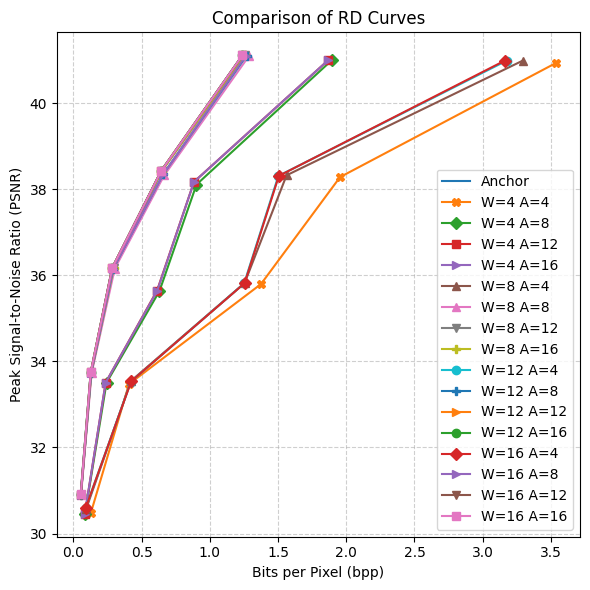

In [70]:
import matplotlib.pyplot as plt
import random

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
         'tab:pink',]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']


plt.figure(figsize=(6, 6))
q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=32, dataset='HEVC-B')
plt.plot(
                bpp_anchor, psnr_anchor,
                label=f'Anchor',                
            )

# for w in [4]:
for w in [4, 8, 12, 16]:
    for a in [4, 8, 12, 16]:
    # for a in [16]:
        try:
            q, bpp, psnr = averages_by_quality(
                df_quant,
                w=w, a=a,
                calib_res=256, calib_seq=1000, frames=32,
                dataset='HEVC-B'
            )
            
            color = random.choice(colors)
            marker = random.choice(markers)
            ls = random.choice(linestyles)
            
            bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')

            if bd_rate_val == None:
                continue

            print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
            
            plt.plot(
                bpp, psnr,
                label=f'W={w} A={a}',
                marker=marker,
                # linestyle=ls,
                # color=color
            )

            bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
            print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
            
        except ValueError:
            continue

plt.xlabel('Bits per Pixel (bpp)')
plt.ylabel('Peak Signal-to-Noise Ratio (PSNR)')
plt.title('Comparison of RD Curves')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Figure to justify only odd points

BD-Rate (W=16, A=16): 278.30%
BD-Rate (W=16, A=16): -0.00%
BD-Rate (W=16, A=16): -0.00%


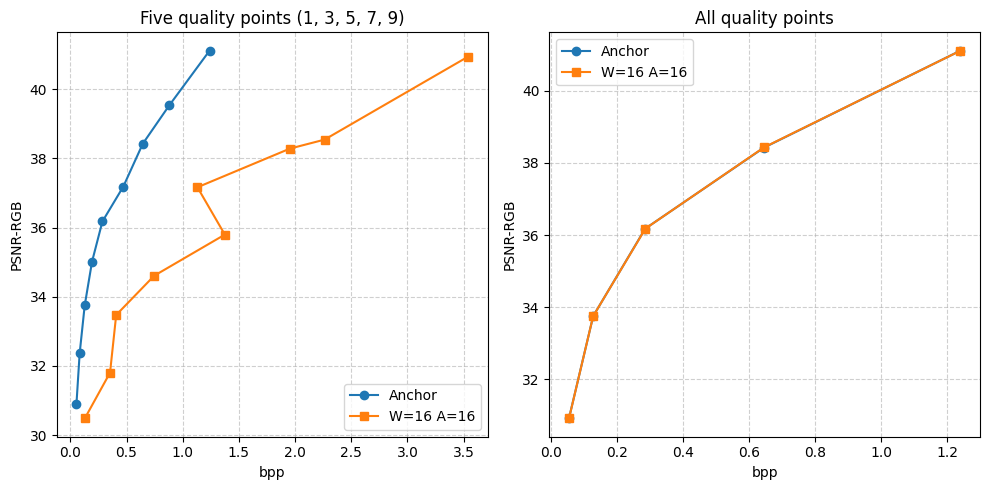

In [71]:
import matplotlib.pyplot as plt
import random

DATASET_JUSTFY = 'HEVC-B'
A_JUSTIFY = 4
W_JUSTIFY = 4

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
         'tab:pink',]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']


plt.figure(figsize=(10, 5))


q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor_allq, frames=32, dataset=DATASET_JUSTFY)
plt.subplot(1, 2, 1)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor',
    marker='o',                
)

try:
    q, bpp, psnr = averages_by_quality(
        df_quant_allq,
        w=W_JUSTIFY, a=A_JUSTIFY,
        calib_res=256, calib_seq=1000, frames=32,
        dataset=DATASET_JUSTFY
    )
    
    color = random.choice(colors)
    marker = random.choice(markers)
    ls = random.choice(linestyles)
    
    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')

       
    
    plt.plot(
        bpp, psnr,
        label=f'W={w} A={a}',
        marker='s',
        # linestyle=ls,
        # color=color
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    
except ValueError as e:
    print (e)

plt.xlabel('bpp')
plt.ylabel('PSNR-RGB')
plt.title('Five quality points (1, 3, 5, 7, 9)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


##########
# SECOND PART

q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=32, dataset=DATASET_JUSTFY)
plt.subplot(1, 2, 2)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor',
    marker='o',                
)



try:
    q, bpp, psnr = averages_by_quality(
        df_quant,
        w=w, a=a,
        calib_res=256, calib_seq=1000, frames=32,
        dataset=DATASET_JUSTFY
    )
    
    color = random.choice(colors)
    marker = random.choice(markers)
    ls = random.choice(linestyles)
    
    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')

    # if bd_rate_val > 7:
    #     continue

    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    
    plt.plot(
        bpp, psnr,
        label=f'W={w} A={a}',
        marker='s',
        # linestyle=ls,
        # color=color
    )

    bd_rate_val = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f'BD-Rate (W={w}, A={a}): {bd_rate_val:.2f}%')
    
except ValueError as e:
    print (e)

plt.xlabel('bpp')
plt.ylabel('PSNR-RGB')
plt.title('All quality points')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.show()

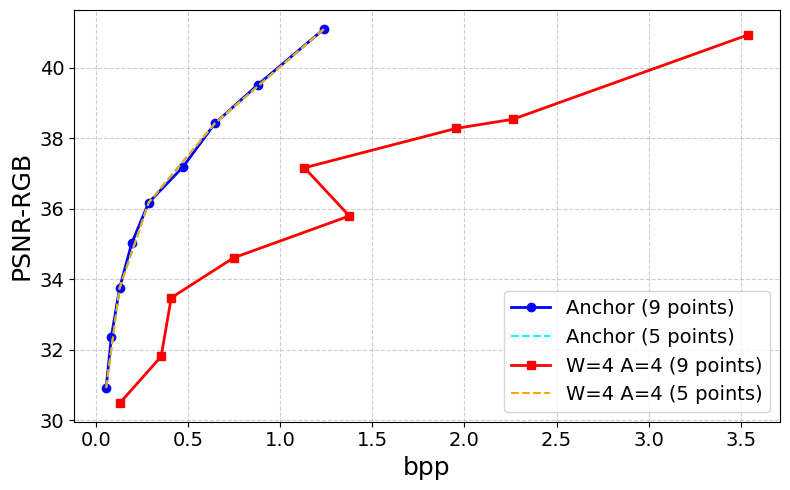

In [72]:
import matplotlib.pyplot as plt
import random

from pyparsing import line

DATASET_JUSTFY = 'HEVC-B'
A_JUSTIFY = 4
W_JUSTIFY = 4



plt.figure(figsize=(8, 5))


q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor_allq, frames=32, dataset=DATASET_JUSTFY)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor (9 points)',
    marker='o',        
    color='blue',
    linewidth=2        
)

q, bpp_anchor, psnr_anchor = averages_by_quality(df_anchor, frames=32, dataset=DATASET_JUSTFY)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor (5 points)',
    linestyle='--',    
    color='cyan'                        
)


##QUANTIZEDS

q, bpp, psnr = averages_by_quality(
    df_quant_allq,
    w=W_JUSTIFY, a=A_JUSTIFY,
    calib_res=256, calib_seq=1000, frames=32,
    dataset=DATASET_JUSTFY
)    

plt.plot(
    bpp, psnr,
    label=f'W={W_JUSTIFY} A={A_JUSTIFY} (9 points)',    
    marker='s',
    # linestyle=ls,
    color='red',
    linewidth=2
)




q, bpp, psnr = averages_by_quality(
    df_quant,
    w=w, a=a,
    calib_res=256, calib_seq=1000, frames=32,
    dataset=DATASET_JUSTFY
)

plt.plot(
    bpp, psnr,
    label=f'W={W_JUSTIFY} A={A_JUSTIFY} (5 points)',    
    linestyle='--',
    color='orange'    
)


plt.xlabel('bpp', fontsize=18)
plt.ylabel('PSNR-RGB', fontsize=18)
plt.legend(fontsize=14)   # aumenta a legenda
plt.tick_params(axis='both', labelsize=14)  # aumenta os ticks dos eixos
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.show()